---
title: Joint probability
---

Phase-type distributions can be extended to model joint probabilities of multiple random variables. This is particularly important in applications like population genetics, where we might be interested in the joint distribution of coalescence times for multiple lineages, or in reliability theory, where we might want the joint distribution of failure times for multiple components. This section shows how to compute exact joint probabilities.

<!-- 
The key idea is that we can embed multiple independent or dependent processes into a single state space, where the state vector encodes the progress of all processes simultaneously. Transitions in this joint state space correspond to events in the individual processes. 

By carefully constructing the edge weights and using reward transformations, we can extract marginal distributions, conditional distributions, and joint distribution functions.

In our rabbit model, we might be interested in the joint distribution of two quantities: the time until the left island is depleted (either by jumping or flooding) and the time until the right island is depleted. These two times are not independent—they are coupled through the rabbits jumping between islands. Let's construct a model that tracks both times simultaneously. 
-->

In [1]:
from phasic import (Graph, with_ipv,
    StateIndexer, Property
)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from typing import Optional
from tqdm.auto import tqdm
from functools import partial
from vscodenb import set_vscode_theme, vscode_theme
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)
_pytest = "pytest" in sys.modules

In [2]:
def coalescent(state, indexer=None):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, state[i]*(state[j]-same)/(1+same)])
    return transitions

Now lets construct the joint probability graph. In addition to a mutation rate, you must specify an upper bound on the number of discrete rewards you want to account for. You can specify a maximum discrete value of each feature (how many tons of each kind you want to account for) using the `reward_limit` keyword argument. This takes both a scalar argument for a maximum applied to all features or an array with a maximum for each feature. You can also use the `tot_reward_limit` keyword argument to specify a maximum on total rewards for each feature combination. Both arguments may be specified to define the upper bound.

Since we only model a subset of feature combinations, the joint distribution is deficient. The deficit is the total probability of feature combinations beyond the upper bound. You can easily compute this as one minus the sum of joint probabilities.

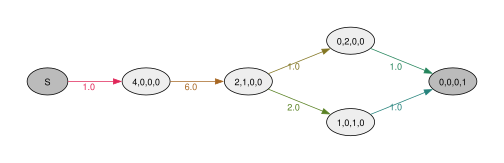

In [3]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)
initial = [nr_samples]+[0]*(nr_samples-1)

graph = Graph(coalescent, ipv=initial, indexer=indexer)
graph.plot()

In [4]:
mutation_rate = 0.1
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit=2, mutation_rate=mutation_rate)
joint_prob_graph.vertices_length()

39

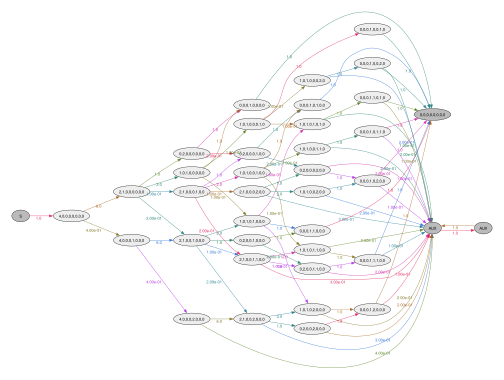

In [5]:
#| label: fig-joint-prob-graph
joint_prob_graph.plot(nodesep=0.3)

Compute the joint probabilities:

In [6]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,0.710227
18,0,1,0,0,0.060979
20,1,0,0,0,0.126890
23,0,0,1,0,0.039457
30,0,2,0,0,0.007658
31,2,0,0,0,0.014744
32,1,0,1,0,0.010394
33,0,0,2,0,0.002989
34,1,1,0,0,0.009097


Deficit:

In [7]:
(1 - joint_prob_table['prob'].sum()).item()

0.016476095092311294

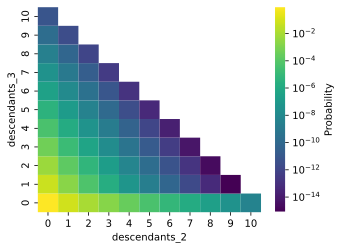

In [8]:
#| label: fig-joint-heatmap


nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)
initial = [nr_samples]+[0]*(nr_samples-1)
graph = Graph(coalescent, ipv=initial, indexer=indexer)
joint_prob_graph = graph.joint_prob_graph(indexer, tot_reward_limit=10, mutation_rate=mutation_rate)
joint_prob_table = joint_prob_graph.joint_prob_table()


ton_pair = ['descendants_2', 'descendants_3']
plot_df = joint_prob_table[ton_pair + ['prob']].groupby(ton_pair).sum().reset_index()   
plot_df = plot_df.pivot(index=ton_pair[1], columns=ton_pair[0], values='prob')

with vscode_theme(style='ticks'):
    ax = sns.heatmap(
        plot_df,
        cmap='viridis',
        cbar_kws={'label': 'Probability'},
        xticklabels=1,
        yticklabels=1,
        norm=LogNorm(),
    )
    ax.set(xlabel=ton_pair[0], ylabel=ton_pair[1])
    ax.invert_yaxis()
plt.show()

Note that the joint probability graph does not have meaningful moments and pdf. E.g., the expectation is inf because of the infinite loop between the trash states:

In [9]:
joint_prob_graph.expectation()

inf

The joint probabilities are extracted as the sojourn times of appropriate transient states connecting only to the absorbing state:

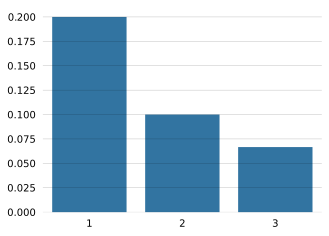

In [10]:
tons = np.arange(1, nr_samples)
marginals = [np.sum(joint_prob_table[f'descendants_{t}'] * joint_prob_table['prob']) for t in tons]
sns.barplot(x=tons, y=marginals);
plt.show()